# Training optimization: PyTorch & Optuna

## Notebook setup

### Imports

In [ ]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.optim as optim
from torchvision import datasets, transforms

# Package imports
from image_classification_tools.pytorch import DataPipeline
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

Using device: cuda


### Fixed hyperparameters

In [ ]:
# Model control
retrain_model = True        # Set to False to load existing model
model_source = 'local'      # 'local' to load from disk, 'huggingface' to download from Hub

# Hyperparameters
initial_channels = 64
num_blocks = 2
learning_rate = 0.0005
epochs = 30
patience = 5

## 1. Load optimized CNN architecture from notebook 04

We'll load the best architecture hyperparameters from the previous optimization study.

In [3]:
# Load architecture optimization study from notebook 04
architecture_study = optuna.load_study(
    study_name='architecture_optimization',
    storage=config.OPTUNA_STORAGE_URL
)

# Get best architecture parameters
arch_params = architecture_study.best_trial.params

print('Best architecture hyperparameters from notebook 04:\n')
for key, value in arch_params.items():
    print(f'  {key}: {value}')

print(f'\nBest validation accuracy: {architecture_study.best_trial.value:.2f}%')

Best architecture hyperparameters from notebook 04:

  batch_size: 256
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 1
  conv_dropout_rate: 0.3970168590808983
  fc_dropout_rate: 0.41794948916615016
  pool_frequency: 4
  filter_double_frequency: 3
  learning_rate: 0.0003262697843356068

Best validation accuracy: 88.79%


## 2. Load and preprocess CIFAR-10 data

CIFAR-10 contains 32x32 color images (3 channels) across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

### 2.1. Visualize sample images

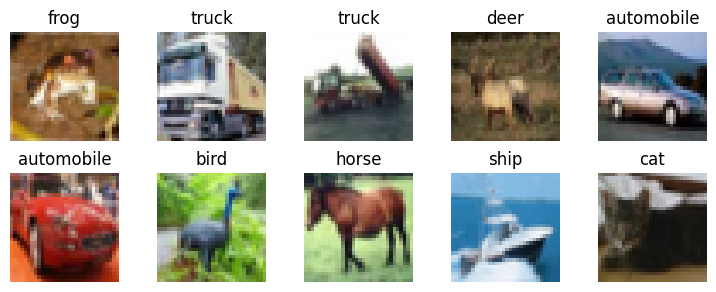

In [ ]:
# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(
    root=config.DATA_DIR,
    train=True,
    transform=config.RGB_TRANSFORM
)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

### 2.2. Create data pipeline

In [ ]:
# Define model path
model_path = config.MODELS_DIR / 'training_optimized_cnn.pth'

# Load existing model if requested
if not retrain_model:
    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='training_optimized_cnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    if model is None:
        print('Proceeding with training...')
        retrain_model = True  # Override to train since no model available
else:
    print('Training new model (retrain_model=True)...')

In [ ]:
if retrain_model:
    # Define the improved model
    model = training.ImprovedCNN(
        input_channels=3,
        num_classes=len(config.CLASS_NAMES),
        initial_channels=initial_channels,
        num_blocks=num_blocks
    ).to(config.DEVICE)

    # Show model architecture
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(model)
    print(f'\nTotal parameters: {total_params:,}')
    print(f'Trainable parameters: {trainable_params:,}')
    print(f'Device: {config.DEVICE}')

    # Calculate memory estimate
    memory_estimate = (total_params * 4) / (1024 ** 3)
    print(f'Estimated model size: {memory_estimate:.2f} GB')

## 4. Optuna training hyperparameter optimization

### 4.1. Define training hyperparameter search space

We'll search over three optimizers (Adam, SGD, RMSprop) and their relevant hyperparameters.

In [ ]:
%%time

if retrain_model:
    # Define optimizer and scheduler
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

    # Train model
    history = training.train(
        model=model, 
        criterion=criterion, 
        optimizer=optimizer,
        scheduler=scheduler,
        train_loader=train_loader,
        val_loader=val_loader, 
        device=config.DEVICE, 
        epochs=epochs,
        patience=patience,
        print_every=250
    )
    print()
else:
    print('Training skipped - using loaded model')

Training hyperparameter search space:

  optimizer: ['Adam', 'AdamW', 'SGD', 'RMSprop']
  learning_rate: (0.0001, 0.1, 'log')
  weight_decay: (1e-05, 0.01, 'log')
  label_smoothing: (0.0, 0.2)
  lr_scheduler: ['none', 'cosine', 'step']
  momentum: (0.85, 0.99)
  nesterov: [True, False]
  beta1: (0.85, 0.95)
  beta2: (0.99, 0.9999)
  alpha: (0.9, 0.999)


### 4.2. Helper function for optimizer creation

In [9]:
def create_optimizer(optimizer_name, model_params, lr, weight_decay, **kwargs):
    '''
    Create an optimizer instance based on the specified configuration.
    
    Args:
        optimizer_name: Name of optimizer ('Adam', 'AdamW', 'SGD', or 'RMSprop')
        model_params: Model parameters (from model.parameters())
        lr: Learning rate
        weight_decay: Weight decay (L2 regularization)
        **kwargs: Optimizer-specific parameters (beta1, beta2, momentum, nesterov, alpha)
    
    Returns:
        optimizer: Configured PyTorch optimizer
    '''

    if optimizer_name == 'Adam':
        beta1 = kwargs.get('beta1', 0.9)
        beta2 = kwargs.get('beta2', 0.999)
        optimizer = optim.Adam(
            model_params,
            lr=lr,
            betas=(beta1, beta2),
            weight_decay=weight_decay
        )
    
    elif optimizer_name == 'AdamW':
        beta1 = kwargs.get('beta1', 0.9)
        beta2 = kwargs.get('beta2', 0.999)
        optimizer = optim.AdamW(
            model_params,
            lr=lr,
            betas=(beta1, beta2),
            weight_decay=weight_decay
        )
    
    elif optimizer_name == 'SGD':
        momentum = kwargs.get('momentum', 0.9)
        nesterov = kwargs.get('nesterov', False) if momentum > 0 else False
        optimizer = optim.SGD(
            model_params,
            lr=lr,
            momentum=momentum,
            nesterov=nesterov,
            weight_decay=weight_decay
        )
    
    elif optimizer_name == 'RMSprop':
        alpha = kwargs.get('alpha', 0.99)
        momentum = kwargs.get('momentum', 0.0)
        optimizer = optim.RMSprop(
            model_params,
            lr=lr,
            alpha=alpha,
            momentum=momentum,
            weight_decay=weight_decay
        )
    
    else:
        raise ValueError(f'Unknown optimizer: {optimizer_name}')
    
    return optimizer

print('Optimizer creation helper function defined')

Optimizer creation helper function defined


### 4.3. Create objective function for training optimization

In [10]:
def create_training_objective(train_loader, val_loader, arch_params, search_space, n_epochs, early_stopping_patience, device):
    '''
    Create an Optuna objective function for training hyperparameter optimization.
    
    Args:
        train_loader: Preloaded training batches on device
        val_loader: Preloaded validation batches on device
        arch_params: Fixed architecture hyperparameters from notebook 04
        search_space: Dictionary defining the hyperparameter search space
        n_epochs: Number of epochs to train per trial
        early_stopping_patience: Patience for early stopping
        device: Device to train on (cpu/cuda)
    
    Returns:
        objective: Optuna objective function
    '''
    
    def objective(trial):

        # Sample optimizer type
        optimizer_name = trial.suggest_categorical('optimizer', search_space['optimizer'])

        # Sample common hyperparameters
        lr = trial.suggest_float('learning_rate', *search_space['learning_rate'][:2], log=True)
        weight_decay = trial.suggest_float('weight_decay', *search_space['weight_decay'][:2], log=True)
        
        # Sample label smoothing and scheduler
        label_smoothing = trial.suggest_float('label_smoothing', *search_space['label_smoothing'])
        lr_scheduler_type = trial.suggest_categorical('lr_scheduler', search_space['lr_scheduler'])

        # Create model with fixed architecture from notebook 04
        model = optimization.create_cnn(
            n_conv_blocks=arch_params['n_conv_blocks'],
            initial_filters=arch_params['initial_filters'],
            n_fc_layers=arch_params['n_fc_layers'],
            conv_dropout_rate=arch_params['conv_dropout_rate'],
            fc_dropout_rate=arch_params['fc_dropout_rate'],
            num_classes=10,
            in_channels=3
        ).to(device)

        # Sample optimizer-specific hyperparameters
        optimizer_kwargs = {}
        
        if optimizer_name in ['Adam', 'AdamW']:
            optimizer_kwargs['beta1'] = trial.suggest_float('beta1', *search_space['beta1'])
            optimizer_kwargs['beta2'] = trial.suggest_float('beta2', *search_space['beta2'])

        elif optimizer_name == 'SGD':
            optimizer_kwargs['momentum'] = trial.suggest_float('momentum', *search_space['momentum'])
            if optimizer_kwargs['momentum'] > 0:
                optimizer_kwargs['nesterov'] = trial.suggest_categorical('nesterov', search_space['nesterov'])

        elif optimizer_name == 'RMSprop':
            optimizer_kwargs['alpha'] = trial.suggest_float('alpha', *search_space['alpha'])
            optimizer_kwargs['momentum'] = trial.suggest_float('momentum', *search_space['momentum'])

        # Create optimizer using helper function
        optimizer = create_optimizer(
            optimizer_name=optimizer_name,
            model_params=model.parameters(),
            lr=lr,
            weight_decay=weight_decay,
            **optimizer_kwargs
        )

        # Loss function with label smoothing
        criterion = torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        
        # Create learning rate scheduler
        scheduler = None
        if lr_scheduler_type == 'cosine':
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
        elif lr_scheduler_type == 'step':
            scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)

        # Train model using trial-specific training function
        best_val_acc = optimization.train_trial(
            model=model,
            optimizer=optimizer,
            criterion=criterion,
            train_loader=train_loader,
            val_loader=val_loader,
            n_epochs=n_epochs,
            trial=trial,
            early_stopping_patience=early_stopping_patience,
            scheduler=scheduler
        )

        return best_val_acc
    
    return objective

In [11]:
# Create objective function
training_objective = create_training_objective(
    train_loader=train_loader,
    val_loader=val_loader,
    arch_params=arch_params,
    search_space=training_search_space,
    n_epochs=n_epochs,
    early_stopping_patience=early_stopping_patience,
    device=config.DEVICE
)

print('Training optimization objective function created')

Training optimization objective function created


### 4.4. Run training optimization

In [12]:
%%time

if run_optimization:
    print('Running training hyperparameter optimization...')
    
    # Delete existing study if desired & it exists
    if start_new_study == True:
        print('Starting new study')

        try:
            optuna.delete_study(study_name=study_name, storage=config.OPTUNA_STORAGE_URL)
            print('Deleted existing study')

        except KeyError:
            print('No existing study found')
    else:
        if config.OPTUNA_DB_PATH.exists():
            print(f'Resuming study from {config.OPTUNA_DB_PATH}')

        else:
            print(f'No prior results found at {config.OPTUNA_DB_PATH}, starting new study')
    
    # Create Optuna study with SQLite storage (maximize validation accuracy)
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=config.OPTUNA_STORAGE_URL,
        load_if_exists=True,  # Resume if study already exists
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
    )
    
    print(f'Study stored at: {config.OPTUNA_DB_PATH}')
    
    # Run optimization
    study.optimize(training_objective, n_trials=n_trials, show_progress_bar=True)

else:
    # Load results from disk
    study = optuna.load_study(
        study_name=study_name,
        storage=config.OPTUNA_STORAGE_URL
    )
    print(f'Study loaded from: {config.OPTUNA_DB_PATH}')

print(f'\nBest validation accuracy: {study.best_trial.value:.2f}%')
print('\nBest training hyperparameters:')

for key, value in study.best_trial.params.items():
    print(f'  {key}: {value}')

print()

Study loaded from: ../data/pytorch/cnn_optimization.db

Best validation accuracy: 91.57%

Best training hyperparameters:
  optimizer: SGD
  learning_rate: 0.010258532143373404
  weight_decay: 0.0021674627774374913
  label_smoothing: 0.003165204969827274
  lr_scheduler: step
  momentum: 0.9560066692269822
  nesterov: True

CPU times: user 67.4 ms, sys: 2.06 ms, total: 69.5 ms
Wall time: 68.3 ms


### 4.5. Visualize optimization results

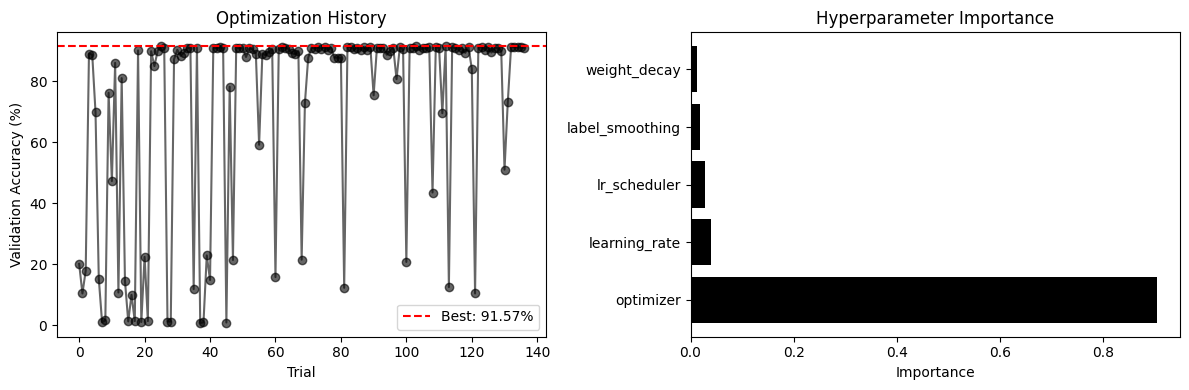

In [ ]:
if not skip_training:
    fig, (ax1, ax2) = plots.plot_learning_curves(history, metrics=['loss', 'accuracy'])
    plt.show()
else:
    print('Skipping learning curves - no training history available')

### 4.6. Analyze optimizer performance

In [14]:
# Analyze performance by optimizer type
optimizer_results = {'Adam': [], 'AdamW': [], 'SGD': [], 'RMSprop': []}

for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        opt_name = trial.params.get('optimizer')
        if opt_name:
            optimizer_results[opt_name].append(trial.value)

print('Optimizer performance summary:\n')

for opt_name, results in optimizer_results.items():
    if results:
        print(f'{opt_name}:')
        print(f'  Trials: {len(results)}')
        print(f'  Mean accuracy: {np.mean(results):.2f}%')
        print(f'  Std accuracy: {np.std(results):.2f}%')
        print(f'  Best accuracy: {np.max(results):.2f}%')
        print()

Optimizer performance summary:

Adam:
  Trials: 9
  Mean accuracy: 51.20%
  Std accuracy: 23.49%
  Best accuracy: 78.26%

AdamW:
  Trials: 8
  Mean accuracy: 77.90%
  Std accuracy: 25.54%
  Best accuracy: 89.14%

SGD:
  Trials: 98
  Mean accuracy: 86.19%
  Std accuracy: 16.03%
  Best accuracy: 91.57%

RMSprop:
  Trials: 11
  Mean accuracy: 19.08%
  Std accuracy: 9.69%
  Best accuracy: 47.33%



## 5. Train final model with best training hyperparameters

### 5.1. Load winning training hyperparameters

In [15]:
# Extract best training hyperparameters
best_training_params = study.best_trial.params

print('Best training hyperparameters:\n')

for key, value in best_training_params.items():
    print(f'  {key}: {value}')

Best training hyperparameters:

  optimizer: SGD
  learning_rate: 0.010258532143373404
  weight_decay: 0.0021674627774374913
  label_smoothing: 0.003165204969827274
  lr_scheduler: step
  momentum: 0.9560066692269822
  nesterov: True


### 5.2. Create final model with optimized architecture

In [16]:
# Create model with best architecture from notebook 04
final_model = optimization.create_cnn(
    n_conv_blocks=arch_params['n_conv_blocks'],
    initial_filters=arch_params['initial_filters'],
    n_fc_layers=arch_params['n_fc_layers'],
    conv_dropout_rate=arch_params['conv_dropout_rate'],
    fc_dropout_rate=arch_params['fc_dropout_rate'],
    pool_frequency=arch_params.get('pool_frequency', 2),
    filter_double_frequency=arch_params.get('filter_double_frequency', 2),
    num_classes=len(config.CLASS_NAMES),
    in_channels=3
).to(config.DEVICE)

# Get total trainable parameters
trainable_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

print(f'{final_model}\n')
print(f'Total parameters: {trainable_params:,}')

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (5): ReLU()
  (6): Dropout(p=0.3970168590808983, inplace=False)
  (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (9): ReLU()
  (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (12): ReLU()
  (13): Dropout(p=0.3970168590808983, inplace=False)
  (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (16): ReLU()
  (17): 

### 5.3. Create optimizer with best training hyperparameters

In [17]:
# Extract optimizer configuration
optimizer_name = best_training_params['optimizer']
lr = best_training_params['learning_rate']
weight_decay = best_training_params['weight_decay']
label_smoothing = best_training_params.get('label_smoothing', 0.0)
lr_scheduler_type = best_training_params.get('lr_scheduler', 'none')

# Extract optimizer-specific parameters
optimizer_kwargs = {}

if optimizer_name in ['Adam', 'AdamW']:
    optimizer_kwargs['beta1'] = best_training_params['beta1']
    optimizer_kwargs['beta2'] = best_training_params['beta2']

elif optimizer_name == 'SGD':
    optimizer_kwargs['momentum'] = best_training_params['momentum']
    optimizer_kwargs['nesterov'] = best_training_params.get('nesterov', False)

elif optimizer_name == 'RMSprop':
    optimizer_kwargs['alpha'] = best_training_params['alpha']
    optimizer_kwargs['momentum'] = best_training_params['momentum']

# Create optimizer using helper function
final_optimizer = create_optimizer(
    optimizer_name=optimizer_name,
    model_params=final_model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
    **optimizer_kwargs
)

# Print configuration
print(f'Using {optimizer_name} optimizer:')
print(f'  lr={lr:.6f}')
print(f'  weight_decay={weight_decay:.6f}')

for key, value in optimizer_kwargs.items():
    print(f'  {key}={value}')

# Set cross-entropy loss WITH label smoothing (same as trials)
criterion = torch.nn.CrossEntropyLoss(label_smoothing=label_smoothing)
print(f'\nUsing CrossEntropyLoss with label_smoothing={label_smoothing:.3f}')

# Create learning rate scheduler (same as trials)
scheduler = None
if lr_scheduler_type == 'cosine':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(final_optimizer, T_max=n_epochs)
    print(f'Using CosineAnnealingLR scheduler (T_max={n_epochs})')
elif lr_scheduler_type == 'step':
    scheduler = torch.optim.lr_scheduler.StepLR(final_optimizer, step_size=30, gamma=0.1)
    print('Using StepLR scheduler (step_size=30, gamma=0.1)')
else:
    print('No LR scheduler')

Using SGD optimizer:
  lr=0.010259
  weight_decay=0.002167
  momentum=0.9560066692269822
  nesterov=True

Using CrossEntropyLoss with label_smoothing=0.003
Using StepLR scheduler (step_size=30, gamma=0.1)


### 5.4. Train final model

In [18]:
%%time

history = training.train_model(
    model=final_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=final_optimizer,
    device=config.DEVICE,
    epoch_scheduler=scheduler,  # Use same scheduler as trials
    epochs=n_epochs,
    print_every=print_every,
    enable_early_stopping=True,
    early_stopping_patience=early_stopping_patience
)

print()
print(f'Best validation accuracy: {max(history["val_accuracy"]):.2f}%')

Epoch   1/200 - loss: 1.9290 - acc: 23.55% - val_loss: 2.8411 - val_acc: 14.19% - lr: 0.010259
Epoch  10/200 - loss: 0.6864 - acc: 77.08% - val_loss: 0.8612 - val_acc: 70.82% - lr: 0.010259
Epoch  20/200 - loss: 0.4736 - acc: 84.92% - val_loss: 0.5851 - val_acc: 80.37% - lr: 0.010259
Epoch  30/200 - loss: 0.4188 - acc: 86.87% - val_loss: 0.5298 - val_acc: 82.96% - lr: 0.001026
Epoch  40/200 - loss: 0.1922 - acc: 94.79% - val_loss: 0.3076 - val_acc: 90.76% - lr: 0.001026
Epoch  50/200 - loss: 0.1506 - acc: 96.34% - val_loss: 0.3379 - val_acc: 90.21% - lr: 0.001026

Early stopping at epoch 55
Best val_loss: 0.3076 at epoch 40
Restored best model weights

Best validation accuracy: 90.76%
CPU times: user 25min 15s, sys: 633 ms, total: 25min 16s
Wall time: 25min 11s


### 5.6. Learning curves

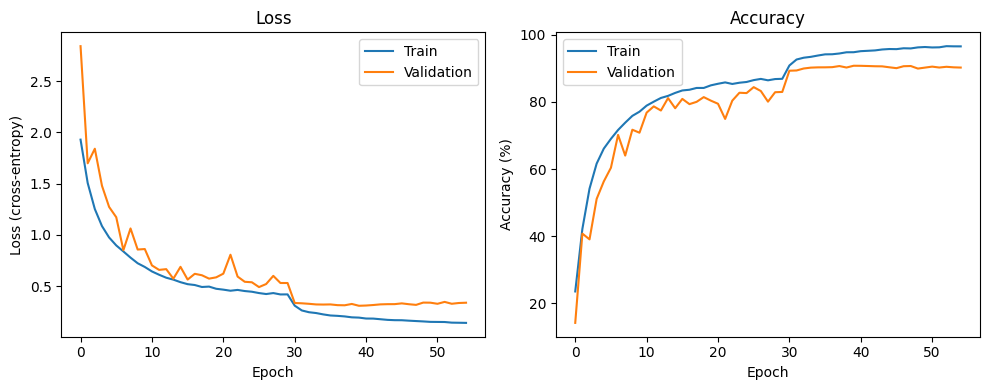

In [19]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 6. Evaluate final model on test set

### 6.1. Calculate test accuracy

In [20]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(
    final_model,
    test_loader
)

print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 89.96%


### 6.2. Per-class accuracy

In [21]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):
    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1
    
    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 89.80%
automobile  : 96.20%
bird        : 82.20%
cat         : 81.10%
deer        : 92.10%
dog         : 85.10%
frog        : 91.30%
horse       : 93.20%
ship        : 94.70%
truck       : 93.90%


### 6.3. Confusion matrix

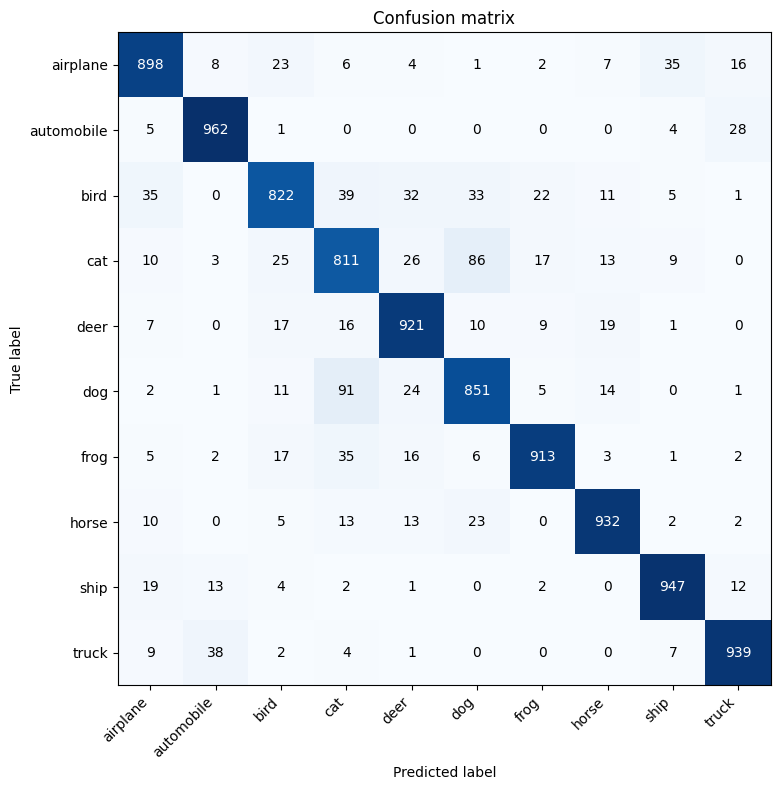

In [22]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 6.4. Predicted class probability distributions

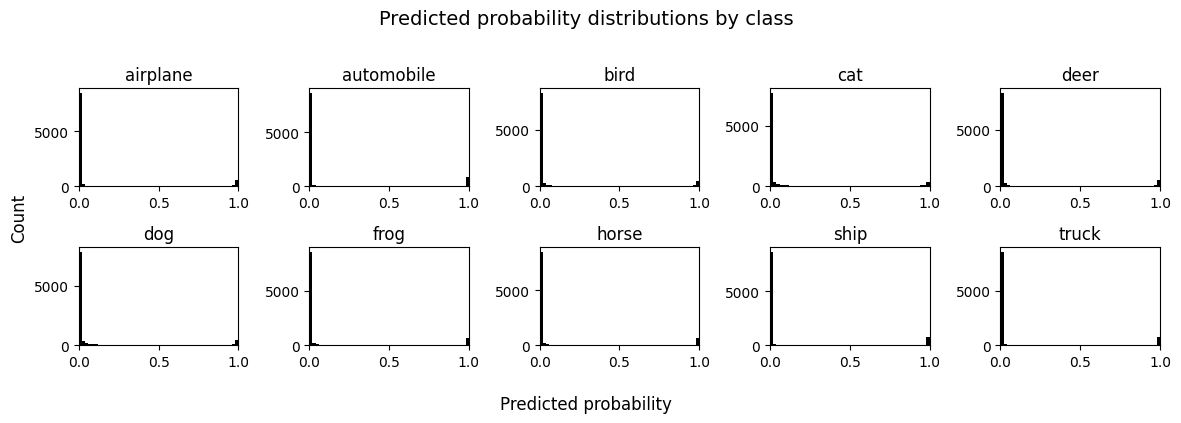

In [23]:
# Get predicted probabilities for all test samples
final_model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = final_model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 6.5. Evaluation curves

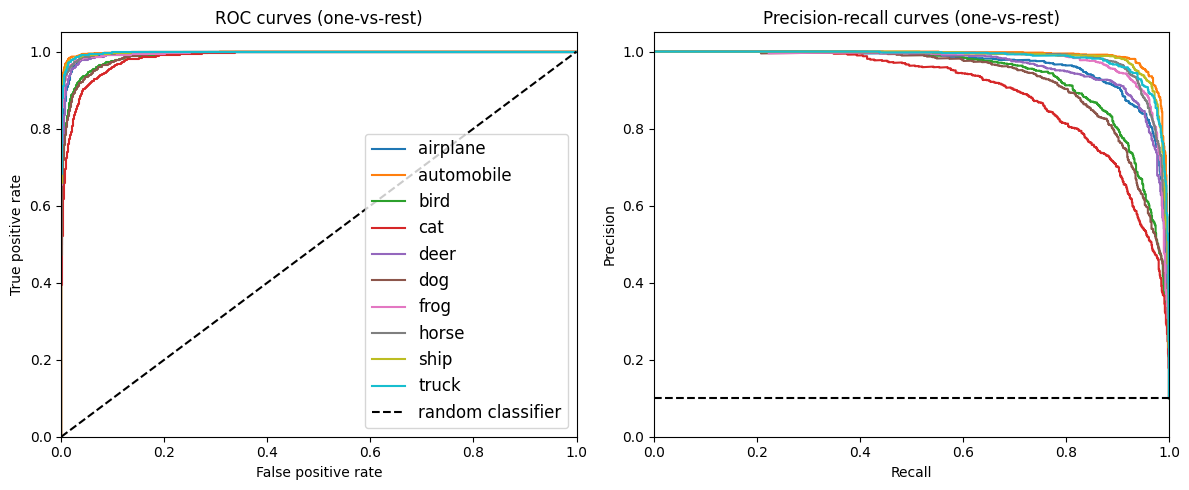

In [24]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 7. Save optimized model

Save the model trained with optimized training hyperparameters.

In [ ]:
if retrain_model:
    # Save trained model (and auto-upload to Hugging Face if configured)
    # Note: This notebook saves state_dict instead of full model
    torch.save(final_model.state_dict(), model_path)
    print(f'Model state dict saved to: {model_path}')
    
    # Upload if configured
    if hf.should_upload_to_huggingface():
        hf.upload_to_huggingface(model_path, 'training_optimized_cnn.pth', test_accuracy)
    
    print(f'Test accuracy: {test_accuracy:.2f}%')
else:
    print(f'Model loaded from: {model_path}')

Model saved to: ../models/pytorch/training_optimized_cnn.pth
Test accuracy: 89.96%


### 7.1. Upload to Hugging Face Hub (optional)

In [ ]:
# Upload model to Hugging Face Hub
# Note: Run 'huggingface-cli login' first to authenticate

upload_to_hf = False  # Set to True to enable upload

if upload_to_hf:
    config.upload_to_huggingface(
        model_path=model_path,
        model_name='training_optimized_cnn.pth',
        commit_message=f'Training-optimized CNN - Test accuracy: {test_accuracy:.2f}%'
    )

## 8. Save test results for comparison

In [26]:
# Save performance results
results_path = config.RESULTS_DIR / 'training_optimized_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in final_model.parameters())
trainable_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params,
    'best_training_params': best_training_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')
print(f'  - Optimizer: {best_training_params["optimizer"]}')

Test results saved to: ../data/pytorch/performance_results/training_optimized_cnn_results.pkl
  - Test accuracy: 89.96%
  - Total parameters: 1,920,970
  - Trainable parameters: 1,920,970
  - Optimizer: SGD
